In [3]:
import pandas as pd
import time

start = time.time()
print("Loading 2009-2010 sheet...")
df_2009 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2009-2010', engine='openpyxl')
print(f"Done in {time.time()-start:.1f}s, shape: {df_2009.shape}")

start = time.time()
print("Loading 2010-2011 sheet...")
df_2010 = pd.read_excel('../data/online_retail_II.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')
print(f"Done in {time.time()-start:.1f}s, shape: {df_2010.shape}")

Loading 2009-2010 sheet...
Done in 94.7s, shape: (525461, 8)
Loading 2010-2011 sheet...
Done in 95.7s, shape: (541910, 8)


In [4]:
df_2009.to_csv('../data/retail_2009_2010.csv', index=False)
df_2010.to_csv('../data/retail_2010_2011.csv', index=False)
print("Saved as CSV")

Saved as CSV


In [5]:
df = pd.concat([df_2009, df_2010], ignore_index=True)
print("Combined shape:", df.shape)
df.head()

Combined shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("\nUnique customers:", df['Customer ID'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Missing values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Unique customers: 5942


In [20]:
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print("Cancelled orders:", cancelled.shape[0])
print("Sample:\n", cancelled[['Invoice', 'Quantity', 'Price']].head())
customer_features = df_clean.groupby('Customer ID').agg(
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max'),
    AvgOrderValue=('TotalPrice', 'mean'),
    TotalItems=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique')
).reset_index()

customer_features['CustomerTenureDays'] = (customer_features['LastPurchase'] - customer_features['FirstPurchase']).dt.days
customer_features.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)

print(customer_features.shape)
customer_features.head()

Cancelled orders: 19494
Sample:
      Invoice  Quantity  Price
178  C489449       -12   2.95
179  C489449        -6   1.65
180  C489449        -4   4.25
181  C489449        -6   2.10
182  C489449       -12   2.95
(5878, 7)


,CustomerID,FirstPurchase,LastPurchase,AvgOrderValue,TotalItems,UniqueProducts,CustomerTenureDays
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,2281.072353,74285,27,400
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,22.266087,3286,126,402
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,39.596078,2714,25,362
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,25.306800,1624,138,570
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,19.670588,197,17,0


In [9]:
df_clean.to_csv('../data/cleaned_retail.csv', index=False)
print("Saved cleaned dataset:", df_clean.shape)

Saved cleaned dataset: (805549, 9)


In [10]:
import datetime as dt


snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                                       # Frequency
    'TotalPrice': 'sum'                                         # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(rfm.shape)
rfm.describe()

Snapshot date: 2011-12-10 12:50:00
(5878, 4)


,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


In [11]:
print(rfm[['Frequency', 'Monetary']].quantile([0.90, 0.95, 0.99, 1.0]))

      Frequency     Monetary
0.90       13.0    5595.3650
0.95       21.0    9535.3360
0.99       46.0   29730.4202
1.00      398.0  608821.6500


In [12]:
freq_cap = rfm['Frequency'].quantile(0.99)
monetary_cap = rfm['Monetary'].quantile(0.99)

print(f"Capping Frequency at {freq_cap}, Monetary at {monetary_cap}")

rfm['Frequency'] = rfm['Frequency'].clip(upper=freq_cap)
rfm['Monetary'] = rfm['Monetary'].clip(upper=monetary_cap)

rfm.describe()

Capping Frequency at 46.0, Monetary at 29730.420199999626


,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,5.785471,2352.912286
std,1715.572666,209.338707,7.630332,4338.246317
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,46.000000,29730.420200


In [13]:
rfm.to_csv('../data/rfm_features.csv', index=False)
print("Saved RFM table:", rfm.shape)

Saved RFM table: (5878, 4)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print(rfm_scaled[:5])

[[ 0.59558355  0.81451995  6.31126843]
 [-0.95227909  0.29025175  0.75622419]
 [-0.60353226 -0.1029494  -0.07688375]
 [-0.87106408 -0.23401645  0.47852385]
 [ 0.51914589 -0.6272176  -0.46532259]]


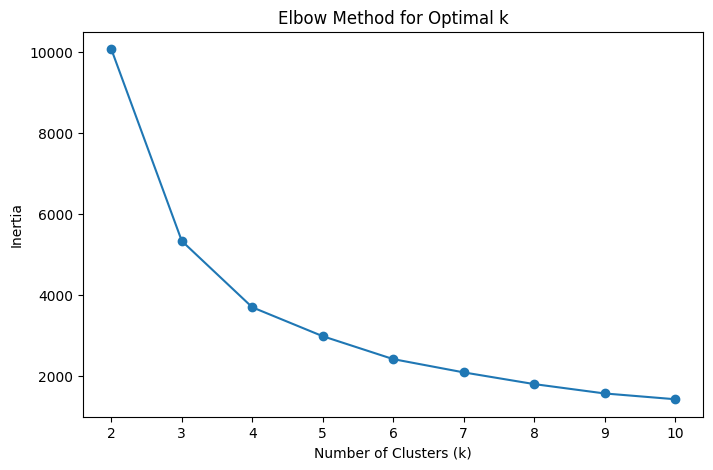

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm['Cluster'].value_counts())

Cluster
0    2996
1    1868
3     812
2     202
Name: count, dtype: int64


In [17]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'})

cluster_profile = cluster_profile.round(1)
print(cluster_profile)

         Recency  Frequency  Monetary  CustomerCount
Cluster                                             
0           83.9        3.8    1202.9           2996
1          475.3        2.0     670.7           1868
2           37.2       34.1   20695.4            202
3           45.0       14.8    5903.2            812


In [18]:
cluster_names = {
    2: 'Champions',
    3: 'Loyal Customers',
    0: 'Potential Loyalists',
    1: 'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)
rfm.to_csv('../data/rfm_segmented.csv', index=False)
print(rfm['Segment'].value_counts())

Segment
Potential Loyalists    2996
At Risk                1868
Loyal Customers         812
Champions               202
Name: count, dtype: int64


In [19]:
rfm['Churned'] = (rfm['Recency'] > 180).astype(int)
print(rfm['Churned'].value_counts())
print("\nChurn rate:", rfm['Churned'].mean().round(3))

Churned
0    3478
1    2400
Name: count, dtype: int64

Churn rate: 0.408


In [21]:
churn_data = rfm.merge(customer_features, on='CustomerID')

print(churn_data.shape)
churn_data.columns.tolist()

(5878, 13)


['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'Cluster',
 'Segment',
 'Churned',
 'FirstPurchase',
 'LastPurchase',
 'AvgOrderValue',
 'TotalItems',
 'UniqueProducts',
 'CustomerTenureDays']

In [22]:
from sklearn.model_selection import train_test_split

feature_cols = ['Frequency', 'Monetary', 'AvgOrderValue', 'TotalItems', 'UniqueProducts', 'CustomerTenureDays']
X = churn_data[feature_cols]
y = churn_data['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train shape: (4702, 6)
Test shape: (1176, 6)
Train churn rate: 0.408
Test churn rate: 0.408


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.66      0.74       696
           1       0.63      0.84      0.72       480

    accuracy                           0.73      1176
   macro avg       0.74      0.75      0.73      1176
weighted avg       0.76      0.73      0.73      1176

ROC-AUC Score: 0.817

Confusion Matrix:
[[458 238]
 [ 76 404]]


In [25]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

              Feature  Importance
5  CustomerTenureDays    0.421622
3          TotalItems    0.166943
0           Frequency    0.154618
1            Monetary    0.118381
4      UniqueProducts    0.078073
2       AvgOrderValue    0.060363


In [26]:
import joblib

joblib.dump(rf_model, '../models/churn_model.joblib')
joblib.dump(feature_cols, '../models/churn_features.joblib')
print("Churn model saved")

Churn model saved


In [27]:
daily_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales.columns = ['ds', 'y'] 
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print(daily_sales.shape)
daily_sales.head()
print("\nDate range:", daily_sales['ds'].min(), "to", daily_sales['ds'].max())

(604, 2)

Date range: 2009-12-01 00:00:00 to 2011-12-09 00:00:00


In [4]:
from prophet import Prophet

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model_prophet.fit(daily_sales)

# Forecast 90 days into the future
future = model_prophet.make_future_dataframe(periods=90)
forecast = model_prophet.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

11:23:19 - cmdstanpy - INFO - Chain [1] start processing
11:23:21 - cmdstanpy - INFO - Chain [1] done processing


            ds          yhat    yhat_lower    yhat_upper
684 2012-02-28  28842.254201  12866.104315  44980.543722
685 2012-02-29  25921.081321   9692.018585  41291.283612
686 2012-03-01  32734.924449  16110.313284  46751.488121
687 2012-03-02  22640.406131   7230.127588  39247.297717
688 2012-03-03 -18705.801390 -34205.560208  -1677.977085
689 2012-03-04  12452.493625  -3611.533630  28883.108318
690 2012-03-05  23563.383838   6832.436755  39682.874094
691 2012-03-06  25966.516102  10321.470379  42680.206211
692 2012-03-07  23038.501429   6631.438580  39874.620658
693 2012-03-08  29966.174684  13590.122048  45066.585173


In [3]:
import pandas as pd

df_clean = pd.read_csv('../data/cleaned_retail.csv')
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

daily_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print(daily_sales.shape)
daily_sales.head()

(604, 2)


,ds,y
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [5]:
forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

            ds          yhat    yhat_lower    yhat_upper
684 2012-02-28  28842.254201  12866.104315  44980.543722
685 2012-02-29  25921.081321   9692.018585  41291.283612
686 2012-03-01  32734.924449  16110.313284  46751.488121
687 2012-03-02  22640.406131   7230.127588  39247.297717
688 2012-03-03      0.000000      0.000000      0.000000
689 2012-03-04  12452.493625      0.000000  28883.108318
690 2012-03-05  23563.383838   6832.436755  39682.874094
691 2012-03-06  25966.516102  10321.470379  42680.206211
692 2012-03-07  23038.501429   6631.438580  39874.620658
693 2012-03-08  29966.174684  13590.122048  45066.585173


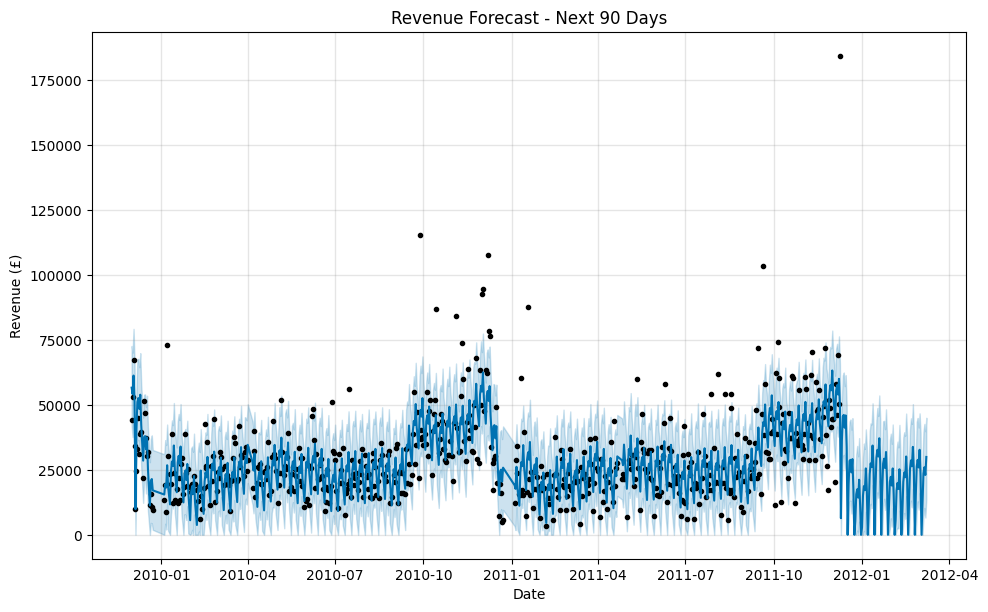

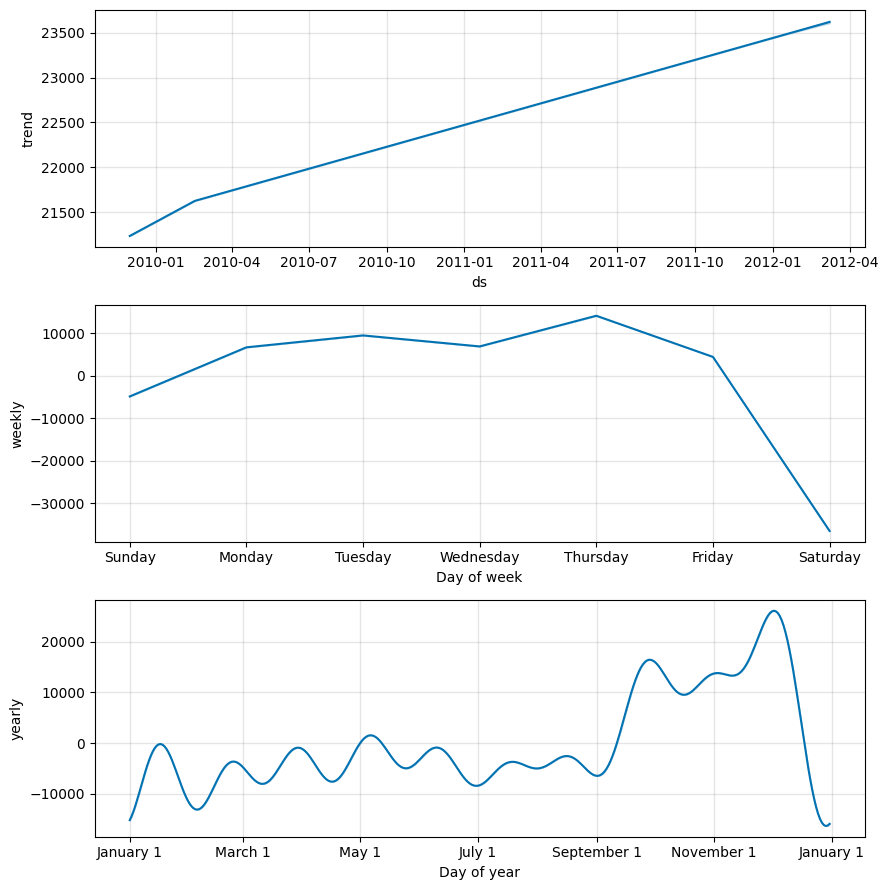

In [6]:
import matplotlib.pyplot as plt

fig = model_prophet.plot(forecast)
plt.title('Revenue Forecast - Next 90 Days')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.show()


fig2 = model_prophet.plot_components(forecast)
plt.show()

In [7]:
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
print(df_clean['DayOfWeek'].value_counts())

DayOfWeek
Thursday     161664
Tuesday      136794
Wednesday    136501
Sunday       136329
Monday       128359
Friday       105502
Saturday        400
Name: count, dtype: int64


In [8]:
full_range = pd.date_range(daily_sales['ds'].min(), daily_sales['ds'].max(), freq='D')
missing_dates = full_range.difference(daily_sales['ds'])
print(f"Missing days: {len(missing_dates)}")
print(missing_dates[:10])

print(daily_sales.sort_values('y', ascending=False).head(3))

Missing days: 135
DatetimeIndex(['2009-12-12', '2009-12-19', '2009-12-24', '2009-12-25',
               '2009-12-26', '2009-12-27', '2009-12-28', '2009-12-29',
               '2009-12-30', '2009-12-31'],
              dtype='datetime64[ns]', freq=None)
            ds          y
603 2011-12-09  184367.28
243 2010-09-27  115243.44
304 2010-12-07  107590.62


In [9]:
import joblib

joblib.dump(model_prophet, '../models/forecast_model.joblib')
print("Forecast model saved")

Forecast model saved


In [12]:
master_customers = churn_data.copy()
master_customers.to_csv('../data/master_customers.csv', index=False)
print(master_customers.shape)
master_customers.head()

(5878, 13)


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,Churned,FirstPurchase,LastPurchase,AvgOrderValue,TotalItems,UniqueProducts,CustomerTenureDays
0,12346,326,12,29730.4202,2,Champions,1,2009-12-14 08:34:00,2011-01-18 10:01:00,2281.072353,74285,27,400
1,12347,2,8,5633.3200,3,Loyal Customers,0,2010-10-31 14:20:00,2011-12-07 15:52:00,22.266087,3286,126,402
2,12348,75,5,2019.4000,0,Potential Loyalists,0,2010-09-27 14:59:00,2011-09-25 13:13:00,39.596078,2714,25,362
3,12349,19,4,4428.6900,0,Potential Loyalists,0,2010-04-29 13:20:00,2011-11-21 09:51:00,25.306800,1624,138,570
4,12350,310,1,334.4000,1,At Risk,1,2011-02-02 16:01:00,2011-02-02 16:01:00,19.670588,197,17,0


In [11]:
import pandas as pd


df_clean = pd.read_csv('../data/cleaned_retail.csv')
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

rfm = pd.read_csv('../data/rfm_segmented.csv')

rfm['Churned'] = (rfm['Recency'] > 180).astype(int)

customer_features = df_clean.groupby('Customer ID').agg(
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max'),
    AvgOrderValue=('TotalPrice', 'mean'),
    TotalItems=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique')
).reset_index()

customer_features['CustomerTenureDays'] = (customer_features['LastPurchase'] - customer_features['FirstPurchase']).dt.days
customer_features.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)


churn_data = rfm.merge(customer_features, on='CustomerID')

print(churn_data.shape)
churn_data.columns.tolist()

(5878, 13)


['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'Cluster',
 'Segment',
 'Churned',
 'FirstPurchase',
 'LastPurchase',
 'AvgOrderValue',
 'TotalItems',
 'UniqueProducts',
 'CustomerTenureDays']

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm = pd.read_csv('../data/rfm_segmented.csv')

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

print("Rebuilt scaler and kmeans model")

Rebuilt scaler and kmeans model


In [2]:
import joblib

joblib.dump(kmeans, '../models/kmeans_model.joblib')
joblib.dump(scaler, '../models/rfm_scaler.joblib')
print("Saved clustering artifacts")

Saved clustering artifacts
